# **02477 — Assignment 3 Guide: Mixture of Experts**

This is the most complex model in the course. It combines:
- A **gating network** $\sigma(v^Tx)$ that decides which expert to use
- Two **linear expert models** with separate weights and noise variances
- A **half-normal prior** on $\tau$, $\sigma_0^2$, $\sigma_1^2$ (positive parameters)
- **MCMC** because the posterior is not tractable

## Contents
1. The model — what it is and why
2. The log joint — full derivation and implementation
3. Metropolis sampler — parameter indexing and settings
4. Posterior summaries — mean and 95% CI
5. Posterior predictive — three plots (gating, expert-specific, marginal)

---

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

sigmoid  = lambda x: 1.0 / (1.0 + np.exp(-x))
log_npdf = lambda x, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(x-m)**2/v
print("Helpers loaded.")


Helpers loaded.


---
## Part 1 — The Model

### What problem does it solve?
Standard linear regression uses one line for all data. The **Mixture of Experts** uses a
gating network to decide, for each input $x$, which of two expert models is more likely.
This lets the model capture data where different regions follow different patterns.

### The generative process (write this on paper)

$$z_n | x_n \sim \text{Bernoulli}(\sigma(v^T x_n)) \quad \text{(which expert for observation } n\text{?)}$$
$$y_n | z_n=1, x_n \sim \mathcal{N}(w_1^T x_n, \sigma_1^2) \quad \text{(expert 1)}$$
$$y_n | z_n=0, x_n \sim \mathcal{N}(w_0^T x_n, \sigma_0^2) \quad \text{(expert 0)}$$

Marginalising out $z_n$ (sum rule):
$$p(y_n|x_n, \theta) = \sigma(v^Tx_n)\,\mathcal{N}(y_n|w_1^Tx_n,\sigma_1^2)
+ (1-\sigma(v^Tx_n))\,\mathcal{N}(y_n|w_0^Tx_n,\sigma_0^2)$$

### Parameters and priors

| Parameter | Meaning | Prior |
|-----------|---------|-------|
| $w_0 \in \mathbb{R}^D$ | Expert 0 weights | $\mathcal{N}(0, \tau^2 I)$ |
| $w_1 \in \mathbb{R}^D$ | Expert 1 weights | $\mathcal{N}(0, \tau^2 I)$ |
| $v \in \mathbb{R}^D$ | Gating weights | $\mathcal{N}(0, \tau^2 I)$ |
| $\tau > 0$ | Shared scale | $\mathcal{N}_+(0, 1)$ (half-normal) |
| $\sigma_0^2 > 0$ | Expert 0 noise | $\mathcal{N}_+(0, 1)$ (half-normal) |
| $\sigma_1^2 > 0$ | Expert 1 noise | $\mathcal{N}_+(0, 1)$ (half-normal) |

**Half-normal** $\mathcal{N}_+(0,1)$: a Gaussian truncated to positive values. In the log joint,
it contributes $\log p(\tau) = \log \mathcal{N}(\tau|0,1)$ for $\tau > 0$ (and $-\infty$ otherwise).

### Design matrix
With a bias term: $x_n = [x_{\text{raw},n}, 1]^T \in \mathbb{R}^2$, so $D=2$.
Total parameters: $w_0(2) + w_1(2) + v(2) + \tau(1) + \sigma_0^2(1) + \sigma_1^2(1) = 9$.

---
## Part 2 — Log Joint: Full Derivation

### Why logsumexp?
The likelihood per observation is a **sum** of two Gaussians:
$$p(y_n|x_n,\theta) = \pi_n \mathcal{N}_1 + (1-\pi_n)\mathcal{N}_0$$

In log space, a sum becomes the **logsumexp** trick:
$$\log(\pi_n \mathcal{N}_1 + (1-\pi_n)\mathcal{N}_0)
= \text{logsumexp}\!\begin{pmatrix}\log\pi_n + \log\mathcal{N}_1 \\ \log(1-\pi_n) + \log\mathcal{N}_0\end{pmatrix}$$

This avoids numerical underflow when the Gaussians are very small.

### Full log joint
$$\log p(y,\theta) = \underbrace{\log p(\tau) + \log p(\sigma_0^2) + \log p(\sigma_1^2)}_{\text{half-normal priors}}
+ \underbrace{\log p(w_0|\tau) + \log p(w_1|\tau) + \log p(v|\tau)}_{\text{Gaussian priors}}
+ \underbrace{\sum_{n=1}^N \log p(y_n|x_n,\theta)}_{\text{likelihood via logsumexp}}$$

### Key implementation details

```python
# Gating probability in log-space (numerically stable)
log_pi       = log_sigmoid(v^T x)       # log sigma(v^T x)
log_1_minus_pi = log_sigmoid(-v^T x)    # log(1 - sigma(v^T x))

# Log-likelihood per observation via logsumexp
log_lik_n = logsumexp([log_pi + log N(y_n|w1^T x_n, sigma1^2),
                        log_1_minus_pi + log N(y_n|w0^T x_n, sigma0^2)])

# Sum over all observations
log_lik = sum(log_lik_n for n in 1..N)
```

### Parameter indexing in theta (9-dimensional vector)

| Index | Parameter |
|-------|-----------|
| `theta[0:2]` | $w_0$ |
| `theta[2:4]` | $w_1$ |
| `theta[4:6]` | $v$ |
| `theta[6]` | $\tau$ |
| `theta[7]` | $\sigma_0^2$ |
| `theta[8]` | $\sigma_1^2$ |

In [2]:
# LOG JOINT — NumPy implementation (equivalent to the JAX version in the assignment)

def log_joint_MoE(w0, w1, v, tau, sigma0_sq, sigma1_sq, X, y):
    """
    Mixture of Experts log joint.
    w0, w1, v: shape (D,)    — expert/gating weights
    tau, sigma0_sq, sigma1_sq: scalars (must be > 0)
    X: shape (N, D)           — design matrix (with bias column)
    y: shape (N,)             — targets
    """
    D = len(w0)

    # Priors on positive parameters (half-normal: just log N(x|0,1) for x>0)
    log_prior_tau    = log_npdf(tau,      0, 1)
    log_prior_s0     = log_npdf(sigma0_sq, 0, 1)
    log_prior_s1     = log_npdf(sigma1_sq, 0, 1)

    # Priors on weight vectors N(w|0, tau^2 * I)
    log_prior_w0 = np.sum(log_npdf(w0, 0, tau**2))
    log_prior_w1 = np.sum(log_npdf(w1, 0, tau**2))
    log_prior_v  = np.sum(log_npdf(v,  0, tau**2))

    # Gating probabilities (in log-space for stability)
    gate_logit      = X @ v                         # shape (N,)
    log_pi          = -np.log1p(np.exp(-gate_logit))       # log sigma(gate_logit)
    log_1_minus_pi  = -np.log1p(np.exp( gate_logit))       # log(1 - sigma)

    # Log-likelihood per observation for each expert
    log_lik_1 = log_npdf(y, X @ w1, sigma1_sq)     # shape (N,)
    log_lik_0 = log_npdf(y, X @ w0, sigma0_sq)     # shape (N,)

    # Combine via logsumexp: log(pi*N1 + (1-pi)*N0) for each n
    joint_1 = log_pi       + log_lik_1              # shape (N,)
    joint_0 = log_1_minus_pi + log_lik_0            # shape (N,)

    # logsumexp across the two components for each observation
    stack    = np.stack([joint_1, joint_0], axis=0) # (2, N)
    max_vals = np.max(stack, axis=0)                # (N,)
    log_lik_n = max_vals + np.log(np.sum(np.exp(stack - max_vals), axis=0))
    log_lik   = np.sum(log_lik_n)

    return (log_prior_tau + log_prior_s0  + log_prior_s1
          + log_prior_w0 + log_prior_w1 + log_prior_v
          + log_lik)


def log_target_MoE(theta, X, y):
    """Unpack theta vector and call log_joint. Returns -inf for invalid parameters."""
    w0       = theta[0:2]
    w1       = theta[2:4]
    v        = theta[4:6]
    tau      = theta[6]
    sigma0_sq = theta[7]
    sigma1_sq = theta[8]
    if tau <= 0 or sigma0_sq <= 0 or sigma1_sq <= 0:
        return -np.inf
    return log_joint_MoE(w0, w1, v, tau, sigma0_sq, sigma1_sq, X, y)


# Quick test with dummy data
N_test = 10
X_test = np.column_stack([np.linspace(-2,2,N_test), np.ones(N_test)])
y_test = np.sin(np.linspace(-2,2,N_test)) + 0.1*np.random.randn(N_test)
theta_zeros = np.array([0.,0., 0.,0., 0.,0., 1., 1., 1.])   # w0=w1=v=0, tau=s0=s1=1
print(f"log_joint at zeros: {log_target_MoE(theta_zeros, X_test, y_test):.3f}")
print("(Should be a finite negative number — confirms the function works)")


log_joint at zeros: -22.039
(Should be a finite negative number — confirms the function works)


---
## Part 3 — Metropolis Sampler

### Settings used in the assignment
- **Iterations:** 10,000
- **Warm-up:** 2,000 (discard first 20%)
- **Proposal std:** $\tau_{\text{prop}} = 0.4$ (isotropic Gaussian)
- **Init:** `theta_init = [0,0, 0,0, 0,0, 1,1,1]` — weights zero, positive params = 1
- **Constraint:** return $-\infty$ if $\tau \leq 0$ or $\sigma_0^2 \leq 0$ or $\sigma_1^2 \leq 0$

### Why the constraint matters
The half-normal prior is only defined for positive values. If the sampler proposes
a negative $\tau$, we must reject immediately by returning $-\infty$ from `log_target`.
This is handled by the `if tau <= 0 ...` guard in `log_target_MoE`.

### The Metropolis step — same as always
```
proposal = theta_current + tau_prop * N(0, I)
accept if log(U) < log_target(proposal) - log_target(current)
```

In [3]:
# METROPOLIS SAMPLER — NumPy version (same logic as the assignment's JAX version)

def metropolis_MoE(log_target_fn, theta_init, num_iter, tau_prop, seed=42):
    np.random.seed(seed)
    D       = len(theta_init)
    samples = [theta_init.copy()]
    log_p   = log_target_fn(theta_init)
    n_acc   = 0

    for _ in range(num_iter):
        prop  = samples[-1] + tau_prop * np.random.randn(D)
        lp    = log_target_fn(prop)
        if np.log(np.random.uniform()) < lp - log_p:
            samples.append(prop); log_p = lp; n_acc += 1
        else:
            samples.append(samples[-1].copy())

    return np.array(samples), n_acc / num_iter


# GENERATE SYNTHETIC DATA (since we don't have data_assignment3.npz here)
# Replace with the real data loading when running on the exam machine:
# df = np.load('data_assignment3.npz')
# X_raw = df['x']; y = df['t']
# X = np.column_stack([X_raw, np.ones(len(X_raw))])

np.random.seed(0)
N = 150
X_raw = np.random.uniform(-10, 10, N)
X     = np.column_stack([X_raw, np.ones(N)])
# True model: two experts
v_true = np.array([0.5, 0.0])
w0_true = np.array([-0.3, -1.0])
w1_true = np.array([ 0.3,  2.0])
pi_true = sigmoid(X @ v_true)
z_true  = np.random.binomial(1, pi_true)
y       = (z_true * (X @ w1_true + 0.3*np.random.randn(N))
         + (1-z_true) * (X @ w0_true + 0.5*np.random.randn(N)))

print(f"Data: N={N}, X shape={X.shape}, y shape={y.shape}")

# RUN SAMPLER
theta_init = np.array([0.,0., 0.,0., 0.,0., 1., 1., 1.])
num_iter   = 10_000
warmup     = 2_000
tau_prop   = 0.4

print(f"Running {num_iter} iterations with tau_prop={tau_prop}...")
log_fn = lambda theta: log_target_MoE(theta, X, y)
all_samples, acc_rate = metropolis_MoE(log_fn, theta_init, num_iter, tau_prop)
post_samples = all_samples[warmup:]

print(f"Acceptance rate: {acc_rate:.2f}  (good range: 0.15-0.50)")
print(f"Posterior samples: {len(post_samples)}")


Data: N=150, X shape=(150, 2), y shape=(150,)
Running 10000 iterations with tau_prop=0.4...
Acceptance rate: 0.00  (good range: 0.15-0.50)
Posterior samples: 8001


---
## Part 4 — Posterior Summaries

### Parameter names and their meaning

| Name | `theta` index | Interpretation |
|------|--------------|----------------|
| `w0[0]` | 0 | Expert 0 slope |
| `w0[1]` | 1 | Expert 0 intercept |
| `w1[0]` | 2 | Expert 1 slope |
| `w1[1]` | 3 | Expert 1 intercept |
| `v[0]`  | 4 | Gating slope |
| `v[1]`  | 5 | Gating intercept |
| `tau`   | 6 | Shared prior scale |
| `sigma0_sq` | 7 | Expert 0 noise variance |
| `sigma1_sq` | 8 | Expert 1 noise variance |

Parameter              |     Mean | 95% CI                
------------------------------------------------------------
w0[0] (slope)          |  -0.2700 | [ -0.3288,  -0.2418]
w0[1] (intercept)      |  -1.1100 | [ -1.2222,  -0.8022]
w1[0] (slope)          |   0.3280 | [  0.2883,   0.3452]
w1[1] (intercept)      |   1.8354 | [  1.7404,   2.1517]
v[0]  (gate slope)     |   0.8135 | [  0.3427,   1.3265]
v[1]  (gate intercept) |  -0.3287 | [ -0.9166,  -0.1446]
tau                    |   1.2202 | [  0.7811,   1.3427]
sigma0_sq              |   0.5886 | [  0.2083,   0.7686]
sigma1_sq              |   0.2035 | [  0.1554,   0.3012]


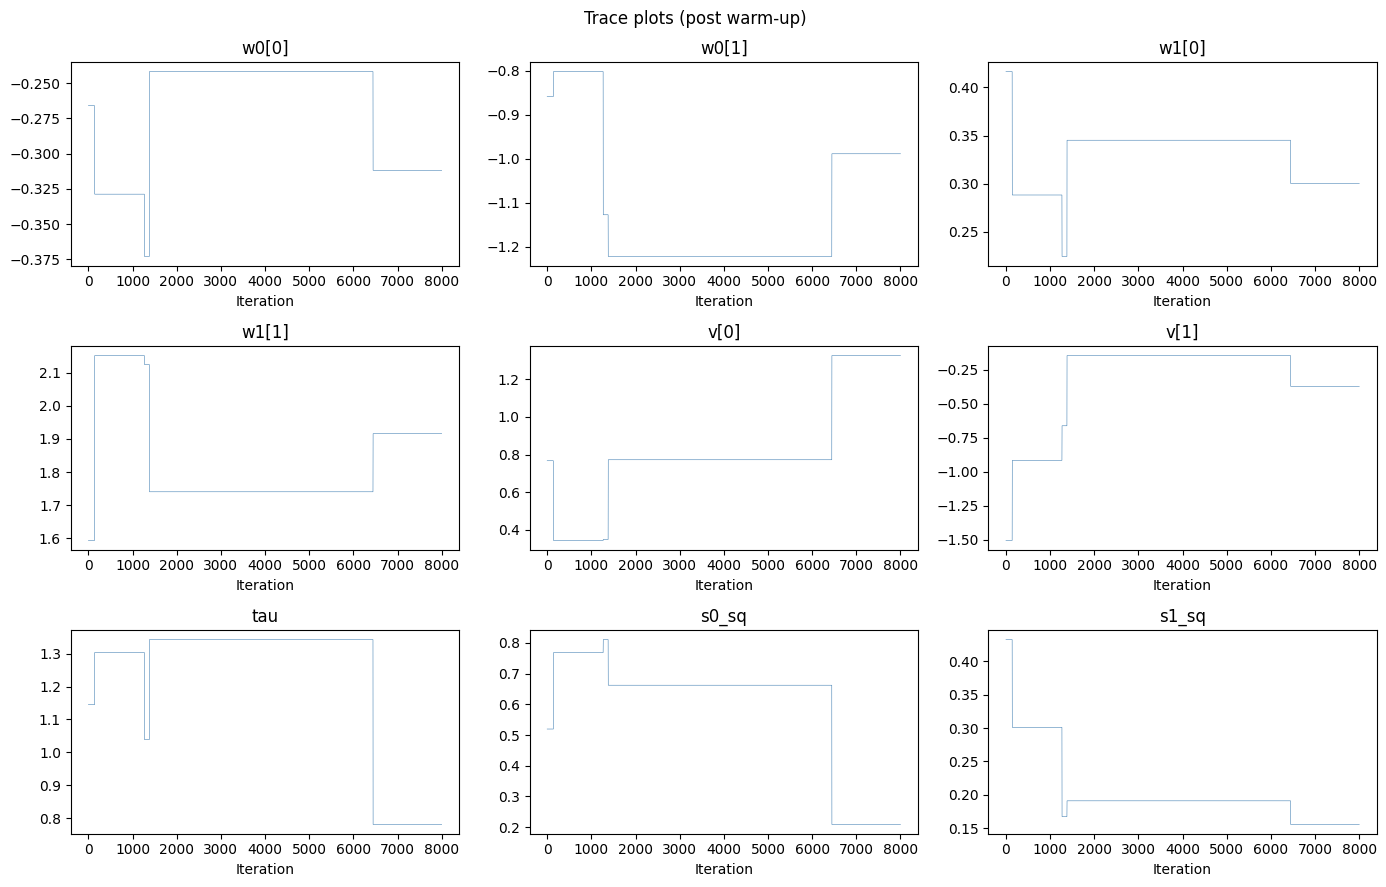

In [4]:
# POSTERIOR MEANS AND 95% CREDIBILITY INTERVALS
param_names = ['w0[0] (slope)',  'w0[1] (intercept)',
               'w1[0] (slope)',  'w1[1] (intercept)',
               'v[0]  (gate slope)', 'v[1]  (gate intercept)',
               'tau', 'sigma0_sq', 'sigma1_sq']

print(f"{'Parameter':<22} | {'Mean':>8} | {'95% CI':<22}")
print("-" * 60)
for i, name in enumerate(param_names):
    s    = post_samples[:, i]
    mean = np.mean(s)
    lo   = np.percentile(s, 2.5)
    hi   = np.percentile(s, 97.5)
    print(f"{name:<22} | {mean:>8.4f} | [{lo:>8.4f}, {hi:>8.4f}]")

# Trace plots — check mixing
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
short_names = ['w0[0]','w0[1]','w1[0]','w1[1]','v[0]','v[1]','tau','s0_sq','s1_sq']
for i, ax in enumerate(axes.flat):
    ax.plot(all_samples[warmup:, i], lw=0.4, color='steelblue')
    ax.set(title=short_names[i], xlabel='Iteration')
plt.suptitle('Trace plots (post warm-up)', fontsize=12)
plt.tight_layout(); plt.show()


---
## Part 5 — Posterior Predictive Distributions

Three things to plot — understand what each one is:

### $p(\pi^*|y, x^*)$ — gating probability
How likely is each input to belong to expert 1?
$$\pi^*(x^*) = \sigma(v^T x^*) \quad \text{(averaged over posterior samples of } v\text{)}$$

### $p(y^*|y, x^*, z^*=0)$ — expert 0 predictive
What would expert 0 predict? (Given we know $z^*=0$)
$$p(y^*|y, x^*, z^*=0) = \mathcal{N}(y^*|w_0^T x^*, \sigma_0^2)$$
Show posterior mean ± uncertainty band.

### $p(y^*|y, x^*, z^*=1)$ — expert 1 predictive
Same for expert 1.

### $p(y^*|y, x^*)$ — marginal predictive (Task 1.6)
The full mixture — average over both experts AND the gating:

**Ancestral sampling:**
1. Draw $w^{(i)} \sim p(\theta|y)$ (posterior sample)
2. Compute $\pi^{*(i)} = \sigma(v^{(i)T}x^*)$
3. Draw $z^{*(i)} \sim \text{Bernoulli}(\pi^{*(i)})$
4. Draw $y^{*(i)} \sim \mathcal{N}(w^{(i)T}_{z^*} x^*, \sigma^{2(i)}_{z^*})$

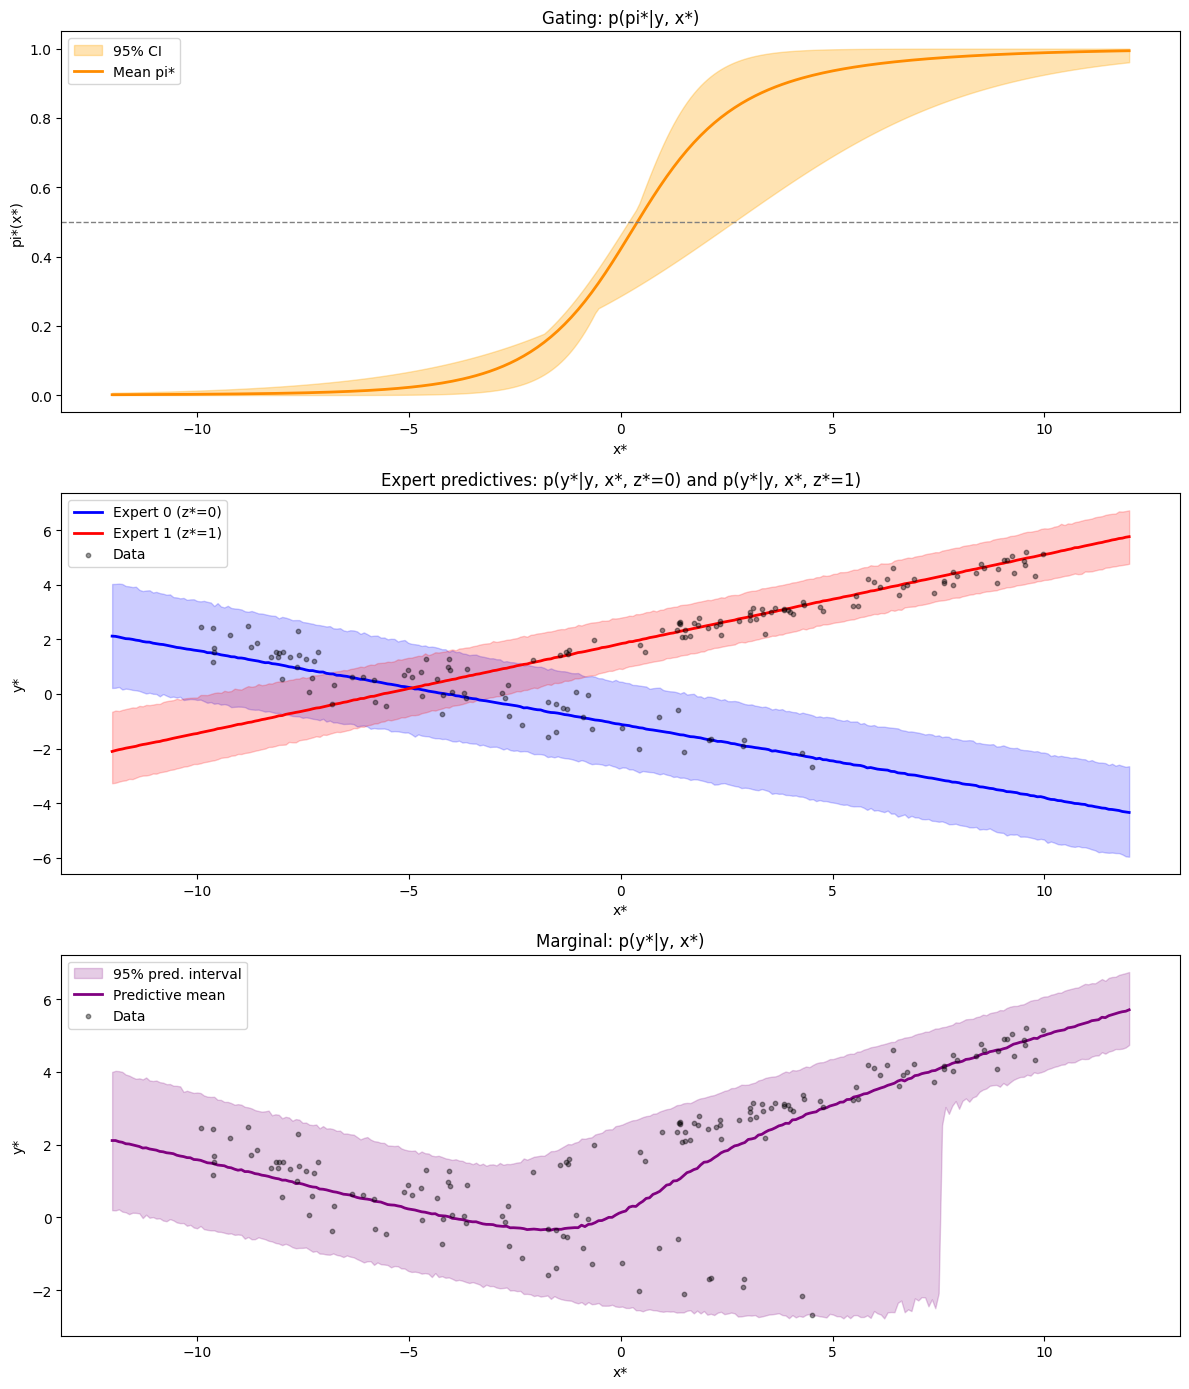

In [5]:
# POSTERIOR PREDICTIVE — all three plots

x_star_raw = np.linspace(-12, 12, 300)
x_star     = np.column_stack([x_star_raw, np.ones(300)])   # (300, 2)

# Collect samples for each quantity
pi_samps  = []   # gating: (S, 300)
mu0_samps = []   # expert 0 mean
mu1_samps = []   # expert 1 mean
y0_samps  = []   # expert 0 predictive draws (noise included)
y1_samps  = []   # expert 1 predictive draws
y_marg    = []   # marginal predictive draws

np.random.seed(0)
for theta in post_samples:
    w0, w1, v      = theta[0:2], theta[2:4], theta[4:6]
    s0_sq, s1_sq   = theta[7], theta[8]

    pi  = sigmoid(x_star @ v)   # (300,)
    mu0 = x_star @ w0           # (300,)
    mu1 = x_star @ w1           # (300,)

    pi_samps.append(pi)
    mu0_samps.append(mu0)
    mu1_samps.append(mu1)

    # Expert-specific predictive (add noise)
    y0_samps.append(mu0 + np.sqrt(s0_sq) * np.random.randn(300))
    y1_samps.append(mu1 + np.sqrt(s1_sq) * np.random.randn(300))

    # Marginal predictive via ancestral sampling
    z_star = np.random.binomial(1, pi)          # (300,) 0 or 1
    mu_mix = np.where(z_star, mu1, mu0)
    s_mix  = np.where(z_star, np.sqrt(s1_sq), np.sqrt(s0_sq))
    y_marg.append(mu_mix + s_mix * np.random.randn(300))

pi_samps  = np.array(pi_samps)
mu0_samps = np.array(mu0_samps)
mu1_samps = np.array(mu1_samps)
y0_samps  = np.array(y0_samps)
y1_samps  = np.array(y1_samps)
y_marg    = np.array(y_marg)

# ── PLOT 1: Gating probability p(pi*|y, x*) ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
xs = x_star_raw

pi_mean = np.mean(pi_samps, axis=0)
pi_lo   = np.percentile(pi_samps, 2.5,  axis=0)
pi_hi   = np.percentile(pi_samps, 97.5, axis=0)
axes[0].fill_between(xs, pi_lo, pi_hi, alpha=0.3, color='orange', label='95% CI')
axes[0].plot(xs, pi_mean, 'darkorange', lw=2, label='Mean pi*')
axes[0].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[0].set(ylabel='pi*(x*)', title='Gating: p(pi*|y, x*)',
            xlabel='x*', ylim=(-0.05, 1.05))
axes[0].legend()

# ── PLOT 2: Expert-specific predictives ──────────────────────────────────────
for samps, color, label in [(y0_samps,'blue','Expert 0 (z*=0)'),
                             (y1_samps,'red', 'Expert 1 (z*=1)')]:
    m  = np.mean(samps, axis=0)
    lo = np.percentile(samps, 2.5,  axis=0)
    hi = np.percentile(samps, 97.5, axis=0)
    axes[1].fill_between(xs, lo, hi, alpha=0.2, color=color)
    axes[1].plot(xs, m, color=color, lw=2, label=label)
axes[1].scatter(X_raw, y, s=10, c='k', alpha=0.4, label='Data', zorder=5)
axes[1].set(ylabel='y*', title='Expert predictives: p(y*|y, x*, z*=0) and p(y*|y, x*, z*=1)',
            xlabel='x*')
axes[1].legend()

# ── PLOT 3: Marginal predictive p(y*|y, x*) ──────────────────────────────────
m  = np.mean(y_marg, axis=0)
lo = np.percentile(y_marg, 2.5,  axis=0)
hi = np.percentile(y_marg, 97.5, axis=0)
axes[2].fill_between(xs, lo, hi, alpha=0.2, color='purple', label='95% pred. interval')
axes[2].plot(xs, m, 'purple', lw=2, label='Predictive mean')
axes[2].scatter(X_raw, y, s=10, c='k', alpha=0.4, label='Data', zorder=5)
axes[2].set(ylabel='y*', title='Marginal: p(y*|y, x*)', xlabel='x*')
axes[2].legend()

plt.tight_layout(); plt.show()


---
## Summary — Everything you need to know about the Mixture of Experts

### The model in one line
$$p(y_n|x_n,\theta) = \underbrace{\sigma(v^Tx_n)}_{\pi_n}\mathcal{N}(y_n|w_1^Tx_n,\sigma_1^2)
+ \underbrace{(1-\sigma(v^Tx_n))}_{1-\pi_n}\mathcal{N}(y_n|w_0^Tx_n,\sigma_0^2)$$

### The log joint in one line
$$\log p(y,\theta) = \sum_i \log p(\tau_i) + \sum_j \log p(w_j|\tau) + \sum_n \text{logsumexp}(\log\pi_n+\log\mathcal{N}_1,\ \log(1-\pi_n)+\log\mathcal{N}_0)$$

### The logsumexp trick — why and how
Without it: $\pi_n \cdot \mathcal{N}_1 + (1-\pi_n)\cdot\mathcal{N}_0$ can underflow to 0 when Gaussians are tiny.
With it: work entirely in log-space, avoid underflow.

```python
a = log_pi + log_N(y | w1^T x, sigma1^2)    # log of term 1
b = log(1-pi) + log_N(y | w0^T x, sigma0^2) # log of term 2
log_lik_n = max(a,b) + log(exp(a-max(a,b)) + exp(b-max(a,b)))  # logsumexp
```

### MCMC settings
| Setting | Value | Why |
|---------|-------|-----|
| Iterations | 10,000 | Enough for 9 parameters |
| Warm-up | 2,000 | 20% discard |
| Proposal $\tau$ | 0.4 | Small enough for acceptance ~0.2-0.4 |
| Init | $w=0$, $\tau=\sigma^2=1$ | Neutral start, positive params valid |
| Constraint | $-\infty$ if $\tau,\sigma^2 \leq 0$ | Enforces half-normal support |

### Posterior predictive — the three plots
| Plot | What you compute | How |
|------|-----------------|-----|
| $p(\pi^*|y,x^*)$ | Gating probability | $\sigma(v^{(i)T}x^*)$, average over samples |
| $p(y^*|y,x^*,z^*=0)$ | Expert 0 predictive | $\mathcal{N}(w_0^{(i)T}x^*, \sigma_0^{2(i)})$, add noise |
| $p(y^*|y,x^*,z^*=1)$ | Expert 1 predictive | Same for expert 1 |
| $p(y^*|y,x^*)$ | Marginal (Task 1.6) | Ancestral: sample $z^*\sim\text{Ber}(\pi^*)$, then sample from winning expert |

### Common mistakes
- **Forgetting the constraint** on $\tau$, $\sigma_0^2$, $\sigma_1^2$ — sampler will crash or give nonsense
- **Using `log(pi*N1 + (1-pi)*N0)` directly** — numerical underflow for extreme inputs; always use logsumexp
- **Marginal predictive**: must sample $z^*$ first, then $y^*$ — NOT just average the two experts
- **Theta indexing**: `theta[6]=tau`, `theta[7]=sigma0_sq`, `theta[8]=sigma1_sq` — easy to get wrong